# Data exploration

In [1]:

import pandas as pd
import numpy as np
import seaborn as sns
import sys
sys.path.append('../')

from config import RAW_DATA_DIR
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt

In [2]:
df = pd.read_csv(RAW_DATA_DIR / "train.csv")

targets = ["event", "time_to_hit_hours"]

X_train, X_test, y_train, y_test = train_test_split(
    df[[c for c in df.columns if c not in targets]], 
    df['event'], 
    test_size=0.2, 
    random_state=222,
    stratify=df['event']
)

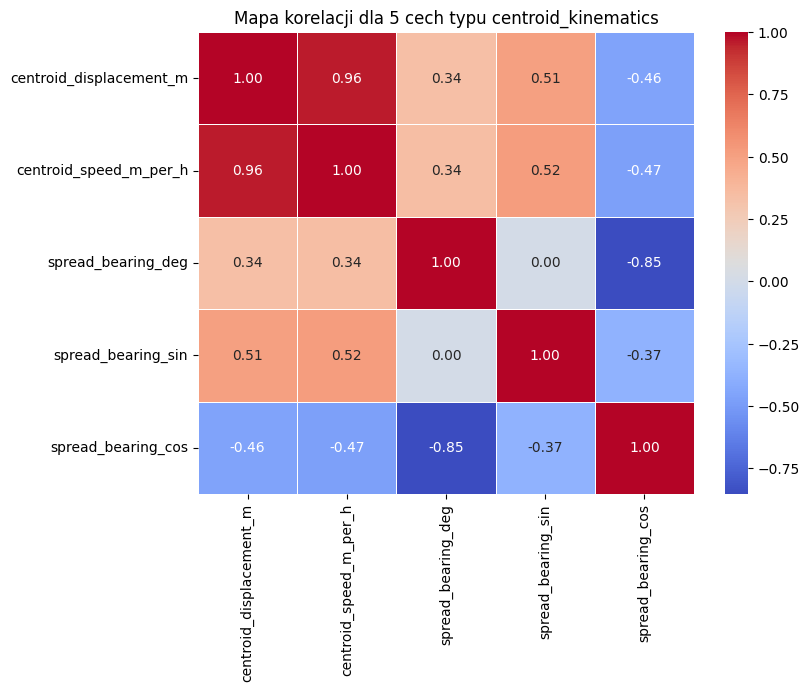

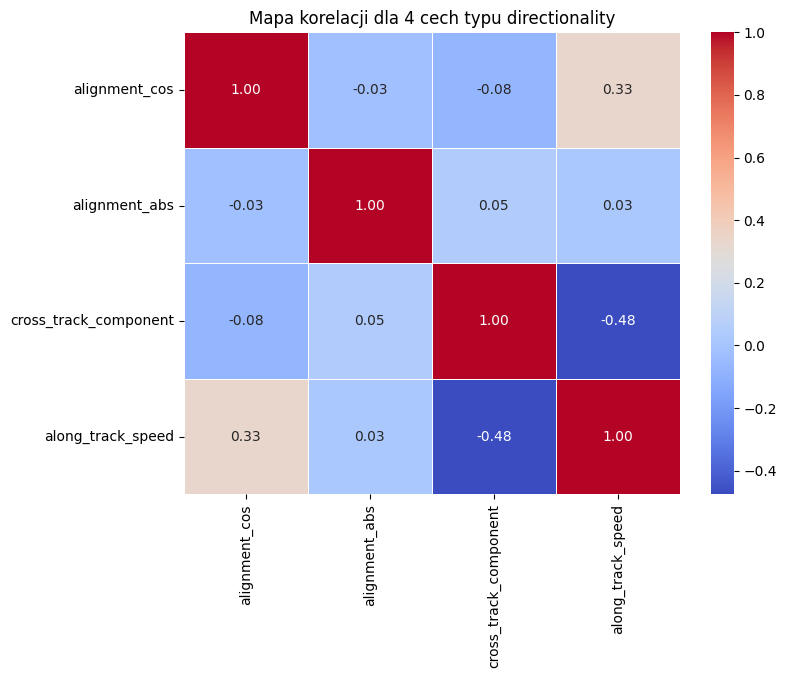

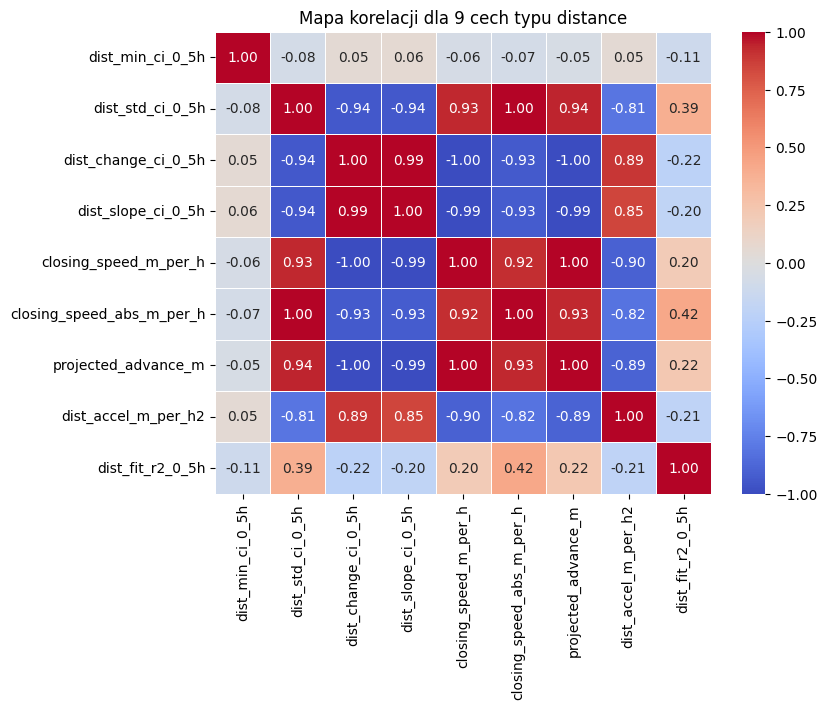

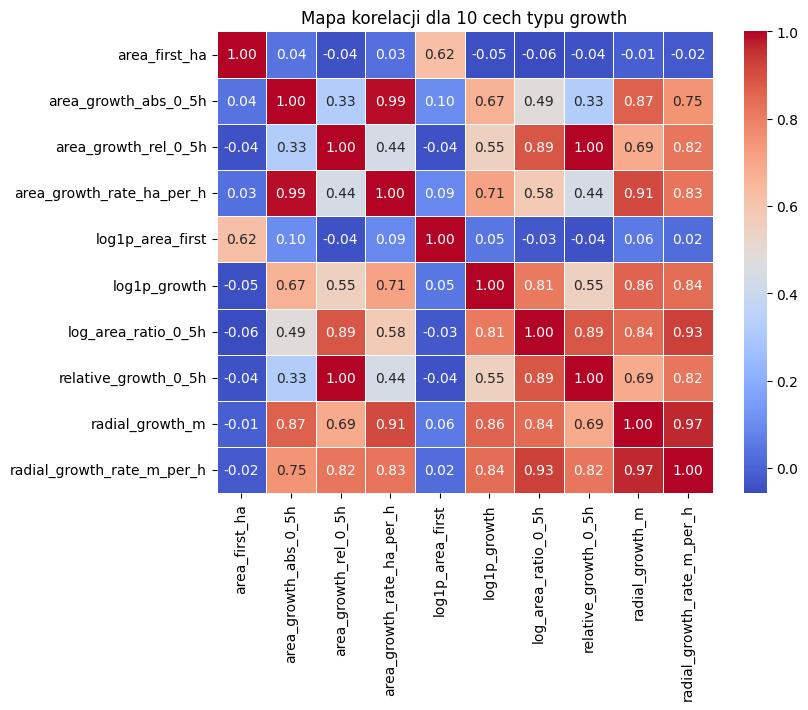

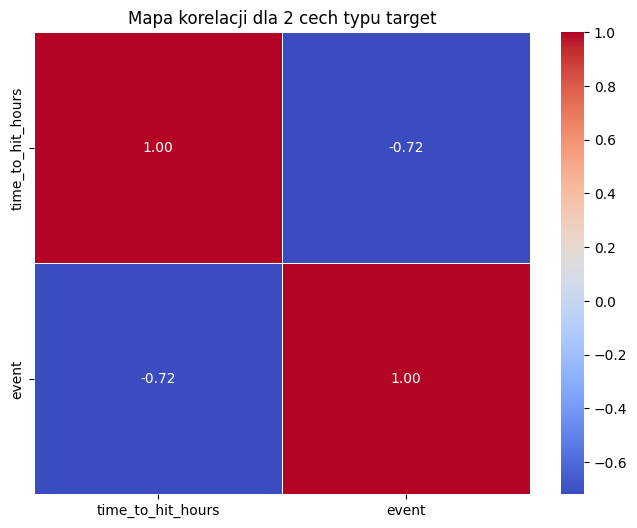

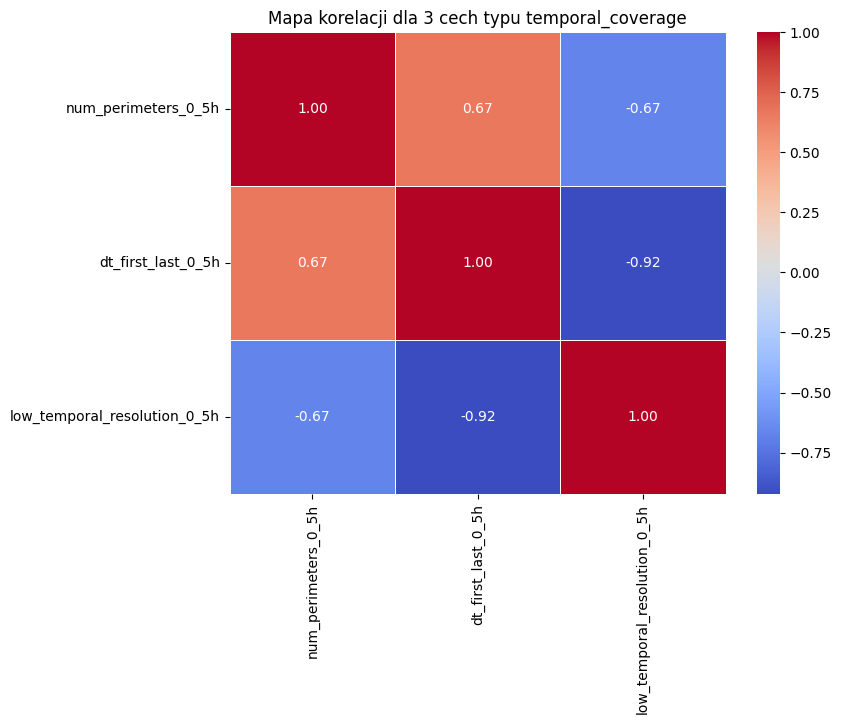

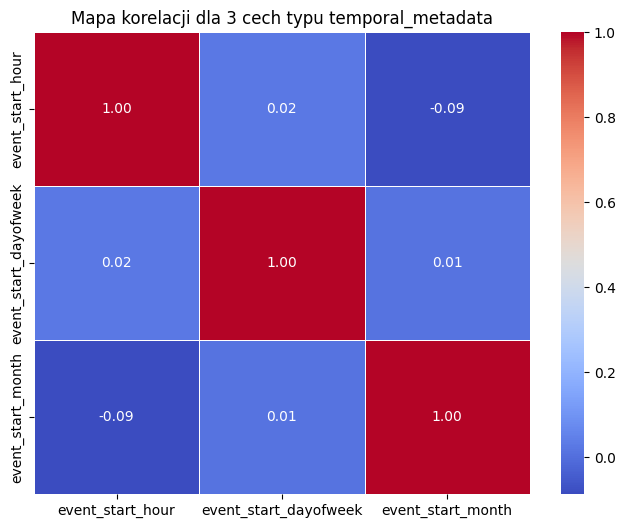

In [25]:
meta_df = pd.read_csv(RAW_DATA_DIR / "metaData.csv")

for feature_type, features in meta_df.groupby("category"):
    
    if feature_type=="targets" or feature_type=="identifier":
        continue
    
    column_names = features["column"].tolist()
    
    corr = df[column_names].corr()
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, linecolor='white')
    plt.title(f'Mapa korelacji dla {len(column_names)} cech typu {feature_type}')
    plt.show()

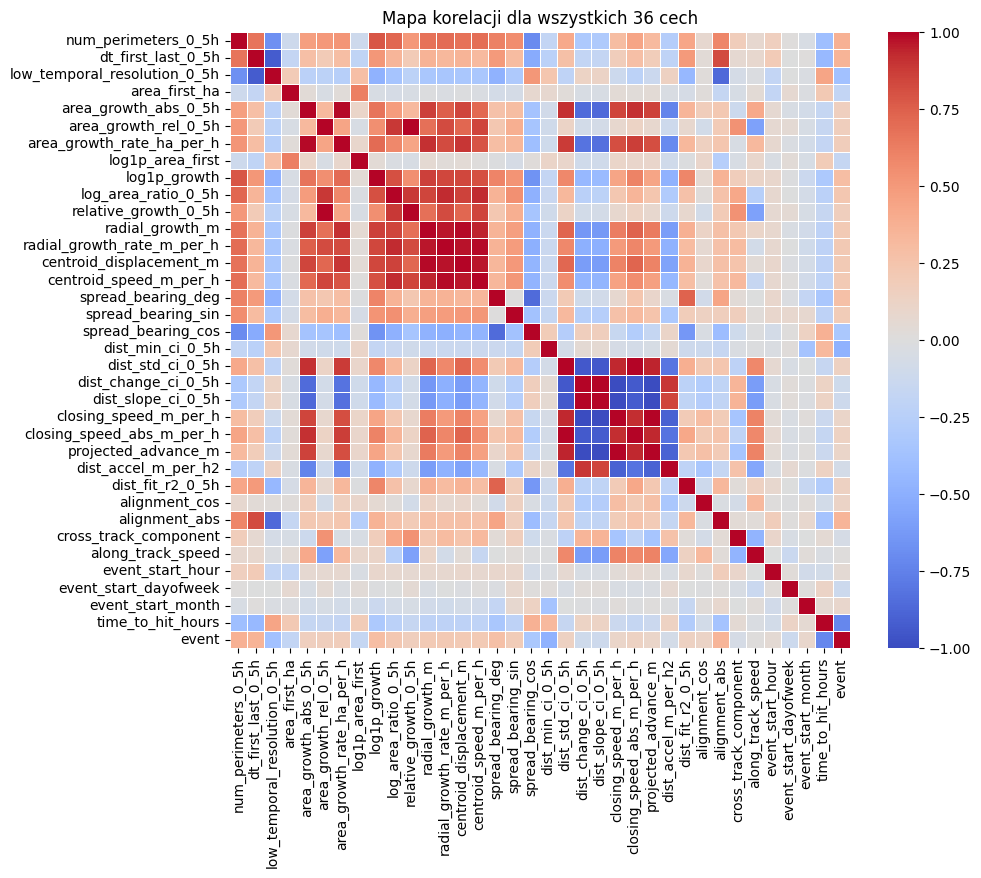

In [24]:
targets = meta_df[meta_df["category"].isin(["targets", "identifier"])]["column"].tolist()
features = df[[c for c in df.columns if c not in targets]]
corr_all_features = features.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_all_features, annot=False, cmap='coolwarm', linewidths=0.5, linecolor='white')
plt.title(f'Mapa korelacji dla wszystkich {len(features.columns)} cech')
plt.show()